1. Load the image reference created in Notebook 01.
2. Select one suitable chest radiograph per study.
3. Load the image.
4. Resize the image to a fixed size.
5. Convert the image to a consistent format.
6. Normalise the image values.
7. Save the processed images for the ViT encoder.

**Output:** `processed_images.npz`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import subprocess
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/dissertation_project/data'
raw_path = f'{base_path}/raw'
processed_path = f'{base_path}/processed'

image_download_path = f'{raw_path}/selected_images'

os.makedirs(image_download_path, exist_ok=True)
os.makedirs(processed_path, exist_ok=True)

print("Image download folder:", image_download_path)

Mounted at /content/drive
Image download folder: /content/drive/MyDrive/dissertation_project/data/raw/selected_images


In [2]:
# Load the image reference from Notebook 01
image_reference = pd.read_csv(
    f'{processed_path}/2_image_reference.csv'
)

print("Image reference shape:", image_reference.shape)

print("\nColumns:")
print(image_reference.columns.tolist())

image_reference.head()

Image reference shape: (3340, 4)

Columns:
['subject_id', 'study_id', 'dicom_id', 'image_path']


,subject_id,study_id,dicom_id,image_path
0,10003052,58630288,21560cb5-ffe886be-2a234166-47975293-e3a97d3f,files/p10/p10003052/s58630288/21560cb5-ffe886b...
1,10003052,58630288,6b13ea59-55cebae9-9033c624-632b5e8b-9ff3e4d2,files/p10/p10003052/s58630288/6b13ea59-55cebae...
2,10003052,58630288,70dd4893-39c01c88-5dcc0b60-5519208f-53cc8045,files/p10/p10003052/s58630288/70dd4893-39c01c8...
3,10011126,58239923,0ed8459b-595d789c-5c8ce379-f33136d7-aab26cc6,files/p10/p10011126/s58239923/0ed8459b-595d789...
4,10011126,58239923,71a6d405-c261ab5b-03707dd7-1b373bba-fc37742f,files/p10/p10011126/s58239923/71a6d405-c261ab5...


In [3]:
# Load image metadata
import getpass
username = input("PhysioNet username/email: ")
password = getpass.getpass("PhysioNet password: ")

PhysioNet username/email: BhavishyaGuntreddi
PhysioNet password: ··········


In [4]:
# Download metadata
metadata_file = f'{raw_path}/mimic-cxr-metadata.csv.gz'

if not os.path.exists(metadata_file):

    result = subprocess.run(
        [
            'wget',
            '-N',
            '-c',
            '--user=' + username,
            '--password=' + password,
            '-O',
            metadata_file,
            metadata_url
        ],
        capture_output=True,
        text=True
    )

    print(result.stdout)
    print(result.stderr)

else:
    print("Metadata file already exists.")

Metadata file already exists.


In [5]:
# Read only the required metadata
metadata = pd.read_csv(
    metadata_file,
    usecols=[
        'dicom_id',
        'ViewPosition'
    ]
)

print("Metadata shape:", metadata.shape)


metadata.head()

Metadata shape: (377110, 2)


,dicom_id,ViewPosition
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,PA
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,LATERAL
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,PA
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,LATERAL
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,AP


In [6]:
# Add view information
image_reference = image_reference.merge(
    metadata,
    on='dicom_id',
    how='left'
)

print(
    image_reference['ViewPosition']
    .value_counts(dropna=False)
)

ViewPosition
AP         1801
PA          622
LATERAL     585
LL          274
NaN          58
Name: count, dtype: int64


In [7]:
# Select one image per study
image_reference['view_priority'] = (
    image_reference['ViewPosition']
    .map({
        'PA': 1,
        'AP': 2
    })
    .fillna(3)
)

selected_images = (
    image_reference
    .sort_values(
        ['study_id', 'view_priority']
    )
    .drop_duplicates(
        subset=['study_id'],
        keep='first'
    )
    .copy()
)

print(
    "Selected images:",
    len(selected_images)
)

print(
    "Unique studies:",
    selected_images['study_id'].nunique()
)

selected_images[
    [
        'subject_id',
        'study_id',
        'dicom_id',
        'image_path',
        'ViewPosition'
    ]
].head(10)

Selected images: 2200
Unique studies: 2200


,subject_id,study_id,dicom_id,image_path,ViewPosition
2758,18249179,50001166,d7477acf-2a537161-8039e338-ecf3fc67-3786b4cb,files/p18/p18249179/s50001166/d7477acf-2a53716...,AP
1945,15906662,50003120,69438681-43e0962a-6869790b-c0e0803f-34577ae0,files/p15/p15906662/s50003120/69438681-43e0962...,AP
1682,15209552,50005491,99ac415e-2af45d36-675118b1-1e93cac8-ca862eab,files/p15/p15209552/s50005491/99ac415e-2af45d3...,AP
1680,15203792,50014721,7e5f7de1-e9ac4aa1-7f5d75c3-11240534-f5383e85,files/p15/p15203792/s50014721/7e5f7de1-e9ac4aa...,AP
3271,19809456,50022513,5feecef2-e806dc59-9c5b6fd4-1d992417-290acbe0,files/p19/p19809456/s50022513/5feecef2-e806dc5...,AP
512,11665092,50029825,b2b3eb6d-a9fb7973-08e34f86-7bf949bb-97e4cd92,files/p11/p11665092/s50029825/b2b3eb6d-a9fb797...,PA
2386,17156429,50029869,b122fc2e-c81872a6-635e6a00-86b20ae0-9b9fc50f,files/p17/p17156429/s50029869/b122fc2e-c81872a...,PA
1597,14953390,50032022,4335eb1e-126aca9f-ed598e0a-a94a658d-928b14a4,files/p14/p14953390/s50032022/4335eb1e-126aca9...,AP
1867,15666511,50038905,c0273969-a0050a8c-22bb2693-777a28e2-8e43f25a,files/p15/p15666511/s50038905/c0273969-a0050a8...,AP
1626,15049054,50041967,d7ac87c1-7fd15822-38f05d50-0ee84ada-4049edcd,files/p15/p15049054/s50041967/d7ac87c1-7fd1582...,AP


In [8]:
# Convert MIMIC-CXR DICOM paths to MIMIC-CXR-JPG paths

selected_images['jpg_path'] = (
    selected_images['image_path']
    .astype(str)
    .str.replace(
        '.dcm',
        '.jpg',
        regex=False
    )
)

# MIMIC-CXR-JPG base URL
base_url = (
    'https://physionet.org/files/'
    'mimic-cxr-jpg/2.1.0/'
)

# Create the actual JPG URL
selected_images['image_url'] = (
    base_url
    + selected_images['jpg_path']
      .astype(str)
      .str.lstrip('/')
)

print(
    selected_images[
        ['study_id', 'image_path', 'jpg_path', 'image_url']
    ].head()
)

      study_id                                         image_path  \
2758  50001166  files/p18/p18249179/s50001166/d7477acf-2a53716...   
1945  50003120  files/p15/p15906662/s50003120/69438681-43e0962...   
1682  50005491  files/p15/p15209552/s50005491/99ac415e-2af45d3...   
1680  50014721  files/p15/p15203792/s50014721/7e5f7de1-e9ac4aa...   
3271  50022513  files/p19/p19809456/s50022513/5feecef2-e806dc5...   

                                               jpg_path  \
2758  files/p18/p18249179/s50001166/d7477acf-2a53716...   
1945  files/p15/p15906662/s50003120/69438681-43e0962...   
1682  files/p15/p15209552/s50005491/99ac415e-2af45d3...   
1680  files/p15/p15203792/s50014721/7e5f7de1-e9ac4aa...   
3271  files/p19/p19809456/s50022513/5feecef2-e806dc5...   

                                              image_url  
2758  https://physionet.org/files/mimic-cxr-jpg/2.1....  
1945  https://physionet.org/files/mimic-cxr-jpg/2.1....  
1682  https://physionet.org/files/mimic-cxr-jpg/2.1.... 

In [9]:
# Create a local path for every image

selected_images['local_path'] = (
    selected_images['study_id']
    .astype(str)
    .apply(
        lambda x: os.path.join(
            image_download_path,
            x + '.jpg'
        )
    )
)

selected_images[
    ['study_id', 'local_path']
].head()

,study_id,local_path
2758,50001166,/content/drive/MyDrive/dissertation_project/da...
1945,50003120,/content/drive/MyDrive/dissertation_project/da...
1682,50005491,/content/drive/MyDrive/dissertation_project/da...
1680,50014721,/content/drive/MyDrive/dissertation_project/da...
3271,50022513,/content/drive/MyDrive/dissertation_project/da...


In [10]:
# Download only the selected JPG images

print(
    "Images to download:",
    len(selected_images)
)

downloaded = 0
skipped = 0
failed = []

for _, row in tqdm(
    selected_images.iterrows(),
    total=len(selected_images),
    desc="Downloading JPG images"
):

    output_path = row['local_path']

    # Skip only if a real file already exists
    if (
        os.path.exists(output_path)
        and os.path.getsize(output_path) > 1000
    ):
        skipped += 1
        continue

    # Remove old zero-byte/invalid file
    if os.path.exists(output_path):
        os.remove(output_path)

    try:

        result = subprocess.run(
            [
                'wget',
                '-c',
                '--user=' + username,
                '--password=' + password,
                '-O',
                output_path,
                row['image_url']
            ],
            capture_output=True,
            text=True
        )

        # Check that wget actually downloaded a real file
        if (
            result.returncode == 0
            and os.path.exists(output_path)
            and os.path.getsize(output_path) > 1000
        ):
            downloaded += 1

        else:

            failed.append({
                'study_id': row['study_id'],
                'url': row['image_url'],
                'status': result.returncode,
                'error': result.stderr[-500:]
            })

            # Remove invalid output
            if os.path.exists(output_path):
                os.remove(output_path)

    except Exception as e:

        failed.append({
            'study_id': row['study_id'],
            'url': row['image_url'],
            'status': 'ERROR',
            'error': str(e)
        })

        if os.path.exists(output_path):
            os.remove(output_path)

print("\nSuccessfully downloaded:", downloaded)
print("Already valid:", skipped)
print("Failed:", len(failed))

Images to download: 2200



Successfully downloaded: 0
Already valid: 2200
Failed: 0


In [11]:
# Check downloaded images

downloaded_files = [
    f for f in os.listdir(image_download_path)
    if f.lower().endswith('.jpg')
]

valid_files = [
    f for f in downloaded_files
    if os.path.getsize(
        os.path.join(image_download_path, f)
    ) > 1000
]

zero_files = [
    f for f in downloaded_files
    if os.path.getsize(
        os.path.join(image_download_path, f)
    ) <= 1000
]

print(
    "Total JPG files:",
    len(downloaded_files)
)

print(
    "Valid JPG files:",
    len(valid_files)
)

print(
    "Invalid/zero-byte files:",
    len(zero_files)
)

print(
    "\nExample valid files:"
)

print(
    valid_files[:10]
)

Total JPG files: 2200
Valid JPG files: 2200
Invalid/zero-byte files: 0

Example valid files:
['57539512.jpg', '56445927.jpg', '53560353.jpg', '55957547.jpg', '54971786.jpg', '57665980.jpg', '55983627.jpg', '52823010.jpg', '55957608.jpg', '59867189.jpg']


In [12]:
# Test one downloaded image

first_image = selected_images.iloc[0]['local_path']

print("Image path:", first_image)
print(
    "File size:",
    os.path.getsize(first_image),
    "bytes"
)

img = Image.open(first_image)

print("Image size:", img.size)
print("Image mode:", img.mode)

display(img)

Output hidden; open in https://colab.research.google.com to view.

In [13]:
# Image preprocessing
IMAGE_SIZE = (224, 224)

def preprocess_image(image_path):

    image = Image.open(image_path)

    # Convert to RGB
    image = image.convert('RGB')

    # Resize
    image = image.resize(
        IMAGE_SIZE,
        Image.Resampling.BILINEAR
    )

    # Convert to NumPy
    image = np.array(image)

    # Normalise to 0-1
    image = image.astype(
        np.float32
    ) / 255.0

    return image

Shape: (224, 224, 3)
Data type: float32
Range: 0.0 to 1.0


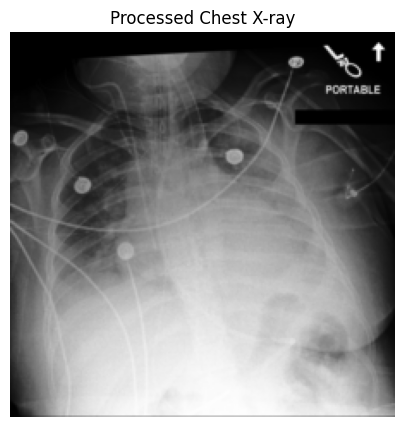

In [14]:
# Test preprocessing
test_image = preprocess_image(
    first_image
)

print(
    "Shape:",
    test_image.shape
)

print(
    "Data type:",
    test_image.dtype
)

print(
    "Range:",
    test_image.min(),
    "to",
    test_image.max()
)

plt.figure(figsize=(5, 5))

plt.imshow(test_image)

plt.axis('off')

plt.title(
    'Processed Chest X-ray'
)

plt.show()

In [15]:
# Process the 2,200 images
processed_images = []
processed_study_ids = []
failed_processing = []

for _, row in tqdm(
    selected_images.iterrows(),
    total=len(selected_images),
    desc="Processing images"
):

    try:

        image = preprocess_image(
            row['local_path']
        )

        processed_images.append(
            image.astype(np.float16)
        )

        processed_study_ids.append(
            row['study_id']
        )

    except Exception as e:

        failed_processing.append({
            'study_id': row['study_id'],
            'error': str(e)
        })

print(
    "Successfully processed:",
    len(processed_images)
)

print(
    "Failed:",
    len(failed_processing)
)

Processing images:   0%|          | 0/2200 [00:00<?, ?it/s]

Successfully processed: 2200
Failed: 0


In [16]:
# Create the array
processed_images = np.stack(
    processed_images
).astype(np.float16)

processed_study_ids = np.array(
    processed_study_ids
)

print(
    "Image array:",
    processed_images.shape
)

print(
    "Study IDs:",
    processed_study_ids.shape
)

print(
    "Memory:",
    round(
        processed_images.nbytes /
        (1024 ** 2),
        2
    ),
    "MB"
)

Image array: (2200, 224, 224, 3)
Study IDs: (2200,)
Memory: 631.64 MB


In [17]:
output_file = (
    f'{processed_path}/processed_images.npz'
)

np.savez_compressed(
    output_file,
    images=processed_images,
    study_ids=processed_study_ids
)

print(
    "Saved:",
    output_file
)

Saved: /content/drive/MyDrive/dissertation_project/data/processed/processed_images.npz


In [18]:
# Verify
data = np.load(
    output_file
)

print(
    "Arrays:",
    data.files
)

print(
    "Images:",
    data['images'].shape
)

print(
    "Study IDs:",
    data['study_ids'].shape
)

Arrays: ['images', 'study_ids']
Images: (2200, 224, 224, 3)
Study IDs: (2200,)
